In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [2]:
# Read in CSV
zillow_df = pd.read_csv("Resources/zillow_yearly.csv")
zillow_df.head()

,Unnamed: 0,RegionID,Neighborhood,City,Year,Avg Annual Home Value
0,0,6018,Montbello,Denver,2000,134737.0
1,1,6018,Montbello,Denver,2001,155990.0
2,2,6018,Montbello,Denver,2002,167373.0
3,3,6018,Montbello,Denver,2003,169344.0
4,4,6018,Montbello,Denver,2004,170715.0


In [3]:
# Drop unnamed index column if present
if 'Unnamed: 0' in zillow_df.columns:
    zillow_df.drop(columns=['Unnamed: 0'], inplace=True)

# Drop rows with missing values
drop_df = zillow_df.dropna()

In [4]:
# One-hot encode categorical columns: Neighborhood and City
df_encoded = pd.get_dummies(drop_df, columns=['Neighborhood', 'City'])
df_encoded.head()

,RegionID,Year,Avg Annual Home Value,Neighborhood_Athmar Park,Neighborhood_Auraria,Neighborhood_Baker,Neighborhood_Barnum,Neighborhood_Barnum West,Neighborhood_Bear Valley,Neighborhood_Belcaro,...,Neighborhood_Washington Park,Neighborhood_Washington Park West,Neighborhood_Washington Virginia Vale,Neighborhood_Wellshire,Neighborhood_West Colfax,Neighborhood_West Highland,Neighborhood_Westwood,Neighborhood_Whittier,Neighborhood_Windsor,City_Denver
0,6018,2000,134737.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,6018,2001,155990.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,6018,2002,167373.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,6018,2003,169344.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,6018,2004,170715.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [5]:
# Set features and target
X = df_encoded.drop(['Avg Annual Home Value'], axis=1)
y = df_encoded['Avg Annual Home Value']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Build the model
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/100


c:\Users\rober\anaconda3\envs\dev\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 192201031680.0000 - mae: 374664.2188 - val_loss: 196808491008.0000 - val_mae: 382945.2812
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 195609706496.0000 - mae: 380784.1562 - val_loss: 196538220544.0000 - val_mae: 382615.5312
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 197295947776.0000 - mae: 381761.0625 - val_loss: 195767943168.0000 - val_mae: 381685.5625
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 186598457344.0000 - mae: 371449.0312 - val_loss: 194232041472.0000 - val_mae: 379830.4375
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 196225728512.0000 - mae: 381708.5000 - val_loss: 191674040320.0000 - val_mae: 376726.3438
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 189102292992.0000 - mae: 369778.2188 - val_loss: 187849228288.0000 - val_mae: 372055.4688
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 178342232064.0000 - mae: 361920.5312 - val_loss: 1827043082

In [7]:

# Evaluate performance
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test MAE: {mae:.2f}, Test MSE: {loss:.2f}")

Test MAE: 61044.40, Test MSE: 7039990272.00


Mean Absolute Error (MAE): $61,313
→ On average, the model’s predictions are off by about $61K.

Mean Squared Error (MSE): ~7.4 billion
→ This is the average of the squared differences between predicted and actual prices. It's high because of large value ranges (typical in housing data).

If home prices range from $200K to $1M, then a $61K MAE could be reasonable (6–10% error).

If most homes are in a narrower range (e.g., $300K–$500K), then it may be too high.


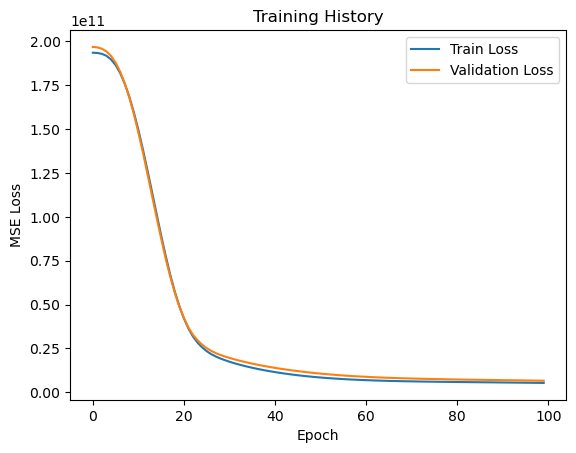

In [8]:
# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.show()

Both training and validation loss steadily decrease and level off — this is a good sign.

The two curves are very close, which indicates:

Minimal overfitting

Good generalization to unseen data

The model converges well around 80–100 epochs.

***Predict Future Pricing***


In [9]:
# 1. Create future neighborhood-year combinations (2024–2035)
base_year = zillow_df["Year"].max()
future_years = list(range(2024, 2036))

In [10]:
# Extract unique neighborhoods and city
neighborhoods = zillow_df[["RegionID", "Neighborhood", "City"]].drop_duplicates()
future_df = neighborhoods.merge(pd.DataFrame({"Year": future_years}), how="cross")

In [11]:

# 2. One-hot encode Neighborhood and City
future_encoded = pd.get_dummies(future_df, columns=["Neighborhood", "City"])

In [12]:
# 3. Align future_encoded to training feature structure
# (match column order, fill missing dummy columns with 0)
for col in X.columns:
    if col not in future_encoded.columns:
        future_encoded[col] = 0
future_encoded = future_encoded[X.columns]

In [13]:
# 4. Scale future data using the same scaler
future_scaled = scaler.transform(future_encoded)

# 5. Predict
future_predictions = model.predict(future_scaled).flatten()

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [14]:
# 6. Attach predictions to the future_df
future_df["Predicted Home Value"] = np.round(future_predictions, 0)
future_df.head(10)

,RegionID,Neighborhood,City,Year,Predicted Home Value
0,6018,Montbello,Denver,2024,446774.0
1,6018,Montbello,Denver,2025,472456.0
2,6018,Montbello,Denver,2026,502504.0
3,6018,Montbello,Denver,2027,533540.0
4,6018,Montbello,Denver,2028,565553.0
5,6018,Montbello,Denver,2029,598455.0
6,6018,Montbello,Denver,2030,632020.0
7,6018,Montbello,Denver,2031,667038.0
8,6018,Montbello,Denver,2032,702170.0
9,6018,Montbello,Denver,2033,737559.0


In [15]:
# 7. Save to CSV
future_df.to_csv("Resources/future_home_value_predictions.csv", index=False)

**Pull neighborhoods with top 10 predicted growth**

In [16]:
# Filter 2024 and 2035 predictions
pred_2024 = future_df[future_df["Year"] == 2024][["RegionID", "Neighborhood", "Predicted Home Value"]]
pred_2035 = future_df[future_df["Year"] == 2035][["RegionID", "Neighborhood", "Predicted Home Value"]]

In [17]:
print("2024 rows:", pred_2024.shape[0])
print("2035 rows:", pred_2035.shape[0])

2024 rows: 76
2035 rows: 76


In [18]:
# Merge to calculate growth
growth_df = pred_2024.merge(
    pred_2035, on=["RegionID", "Neighborhood"], suffixes=("_2024", "_2035")
)

In [19]:
# Calculate growth
growth_df["Growth ($)"] = growth_df["Predicted Home Value_2035"] - growth_df["Predicted Home Value_2024"]
growth_df["Growth (%)"] = (growth_df["Growth ($)"] / growth_df["Predicted Home Value_2024"]) * 100

In [20]:
# Sort and show top 10 neighborhoods by absolute growth ($)
top10_growth = growth_df.sort_values(by="Growth ($)", ascending=False).head(10)
top10_growth.reset_index(drop=True, inplace=True)

top10_growth

,RegionID,Neighborhood,Predicted Home Value_2024,Predicted Home Value_2035,Growth ($),Growth (%)
0,268762,University Park,883413.0,1265003.0,381590.0,43.194973
1,268657,East Colfax,412578.0,791829.0,379251.0,91.922256
2,268742,Southmoor Park,681842.0,1053466.0,371624.0,54.502953
3,268712,Overland,513829.0,884129.0,370300.0,72.066780
4,268775,Wellshire,905971.0,1275381.0,369410.0,40.775036
5,268773,Washington Park West,801246.0,1168805.0,367559.0,45.873428
6,273809,Gateway - Green Valley Ranch,484824.0,851111.0,366287.0,75.550507
7,268740,South Park Hill,799656.0,1165850.0,366194.0,45.793941
8,52070,Fort Logan,569246.0,932596.0,363350.0,63.830048
9,268720,Platt Park,707580.0,1070779.0,363199.0,51.329742


**Plot and Map**

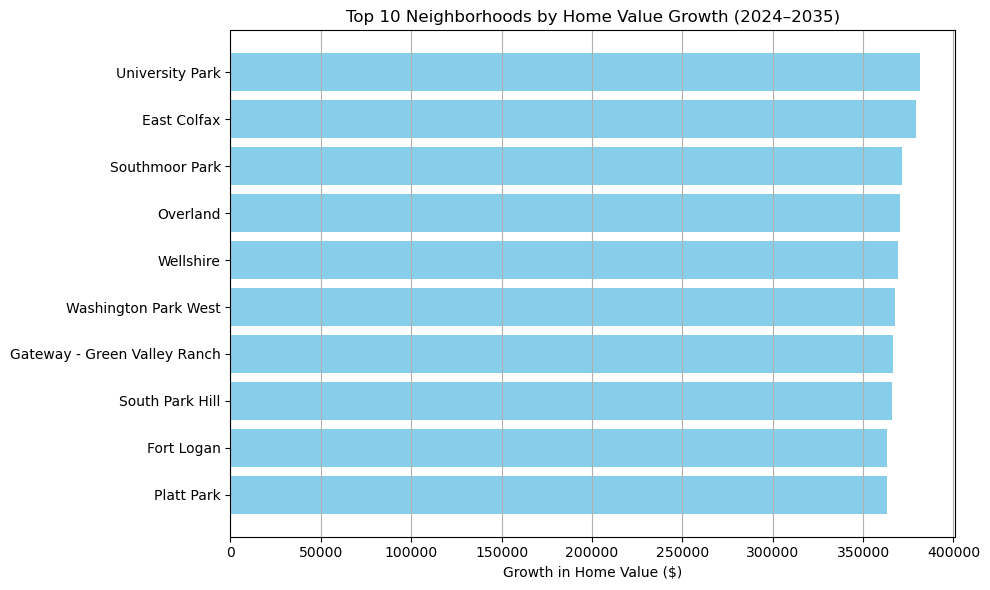

In [21]:
# Sort by $ growth (already done in top10_growth)
plt.figure(figsize=(10, 6))
plt.barh(top10_growth["Neighborhood"], top10_growth["Growth ($)"], color='skyblue')
plt.xlabel("Growth in Home Value ($)")
plt.title("Top 10 Neighborhoods by Home Value Growth (2024–2035)")
plt.gca().invert_yaxis()  # Largest on top
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_29380\1245681966.py:33: UserWarning: Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\rober\anaconda3\envs\dev\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


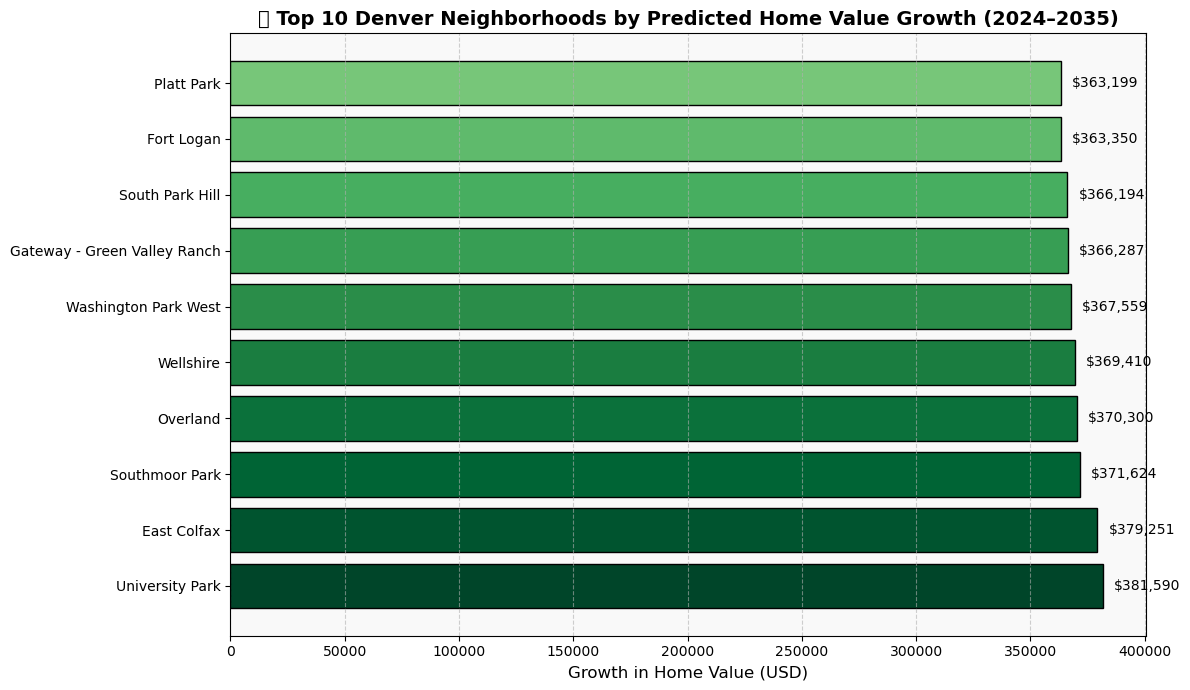

In [22]:
# Sort for better visual flow (just in case)
top10_sorted = top10_growth.sort_values(by="Growth ($)", ascending=True)

# Define color gradient (greens)
colors = plt.cm.YlGn(np.linspace(0.5, 1, len(top10_sorted)))

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top10_sorted["Neighborhood"],
    top10_sorted["Growth ($)"],
    color=colors,
    edgecolor='black'
)

# Add value labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5000,  # position to the right
        bar.get_y() + bar.get_height() / 2,
        f"${int(width):,}",
        va='center',
        fontsize=10,
        color='black'
    )

# Chart titles and labels
plt.xlabel("Growth in Home Value (USD)", fontsize=12)
plt.title("🌆 Top 10 Denver Neighborhoods by Predicted Home Value Growth (2024–2035)", fontsize=14, weight='bold')
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.gca().set_facecolor("#f9f9f9")
plt.gca().invert_yaxis()  # highest growth on top
plt.tight_layout()
plt.show()

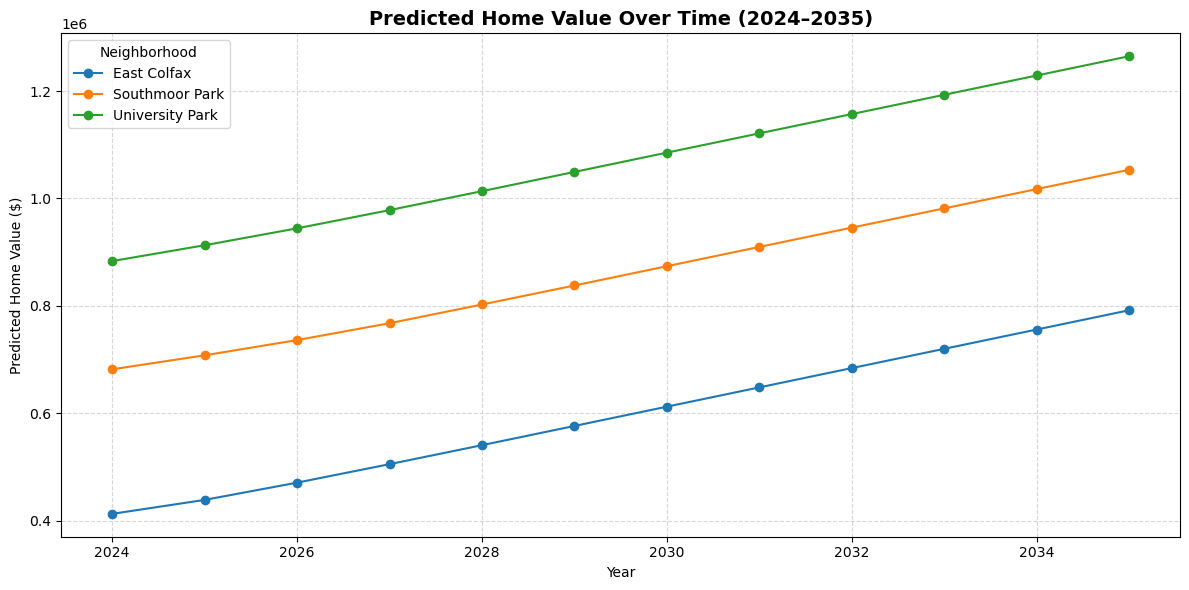

In [23]:
key_hoods = top10_growth["Neighborhood"].head(3).tolist()  # or pick your favorites
subset = future_df[future_df["Neighborhood"].isin(key_hoods)]

plt.figure(figsize=(12, 6))
for name, group in subset.groupby("Neighborhood"):
    plt.plot(group["Year"], group["Predicted Home Value"], marker='o', label=name)

plt.title("Predicted Home Value Over Time (2024–2035)", fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Predicted Home Value ($)")
plt.legend(title="Neighborhood")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\rober\AppData\Local\Temp\ipykernel_29380\100700701.py:47: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\rober\anaconda3\envs\dev\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


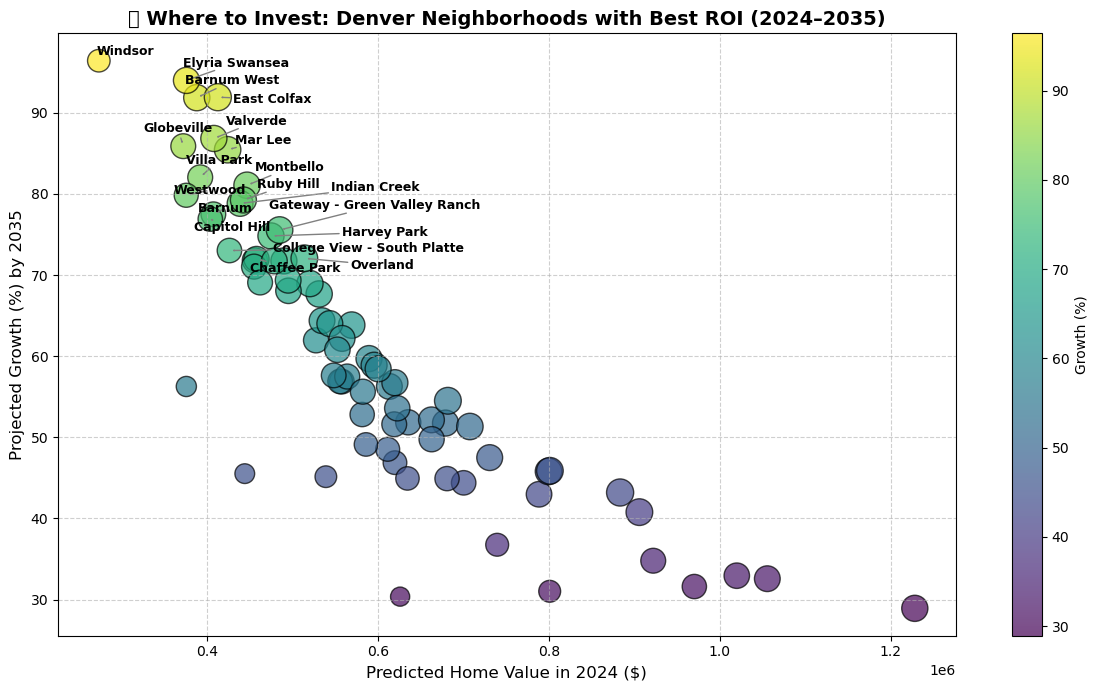

In [27]:
investment_df = growth_df.copy()

# Filter for best investment deals
price_median = investment_df["Predicted Home Value_2024"].median()
growth_threshold = investment_df["Growth (%)"].quantile(0.75)

# Filter top deals
top_deals = investment_df[
    (investment_df["Predicted Home Value_2024"] < price_median) &
    (investment_df["Growth (%)"] > growth_threshold)
]

# Plot base scatter
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    investment_df["Predicted Home Value_2024"],
    investment_df["Growth (%)"],
    s=investment_df["Growth ($)"] / 1000,
    c=investment_df["Growth (%)"],
    cmap="viridis",
    alpha=0.7,
    edgecolor="k"
)

# Filter and prepare label list
texts = []
for _, row in top_deals.iterrows():
    texts.append(
        plt.text(
            row["Predicted Home Value_2024"],
            row["Growth (%)"],
            row["Neighborhood"],
            fontsize=9,
            weight="bold"
        )
    )

# Automatically adjust labels to prevent overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=1))

# Final styling
plt.title("💰 Where to Invest: Denver Neighborhoods with Best ROI (2024–2035)", fontsize=14, weight='bold')
plt.xlabel("Predicted Home Value in 2024 ($)", fontsize=12)
plt.ylabel("Projected Growth (%) by 2035", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.colorbar(scatter, label="Growth (%)")
plt.tight_layout()
plt.show()

In [28]:
import plotly.express as px

# Create a copy of your best investment opportunities
investment_df["Dollar Growth"] = investment_df["Growth ($)"]
investment_df["Percent Growth"] = investment_df["Growth (%)"]
investment_df["2024 Value"] = investment_df["Predicted Home Value_2024"]

# Interactive scatter plot
fig = px.scatter(
    investment_df,
    x="2024 Value",
    y="Percent Growth",
    size="Dollar Growth",
    color="Percent Growth",
    hover_name="Neighborhood",
    hover_data={
        "2024 Value": ":$,",
        "Percent Growth": ":.1f",
        "Dollar Growth": ":$,"
    },
    color_continuous_scale="Viridis",
    title="💰 Where to Invest: Denver Neighborhoods with Best ROI (2024–2035)",
    labels={
        "2024 Value": "Predicted Home Value in 2024 ($)",
        "Percent Growth": "Projected Growth (%) by 2035"
    },
    height=650
)

fig.update_layout(
    title_font=dict(size=18),
    title_x=0.5,
    plot_bgcolor="#f9f9f9"
)

fig.show()
